In [3]:
import numpy as np
import numpy.random as rng
from resources.OTHERS.models import paraboloid_model, true_target_sampler_paraboloid
from resources.OTHERS.models import ridge_switch_model
from src.plot import plot_scatter_xi_list
import matplotlib.pyplot as plt

def sample_true_uncertainty_model_2d(N=10, rng=np.random.default_rng()):
    xa = rng.normal(4.0, 0.5, size=(N, 2))   # aleatoric
    xe = np.tile([2.0, 0.0], (N, 1))         # epistemic (fixed, repeated)
    return true_target_sampler_paraboloid

def prior_sampler_xa(n, lb=-15, ub=15):
    return np.random.uniform(lb, ub, size=(n, 2))

def prep_sim_archive(N_SIM, xi_list):
    # ---- make xi_list a 2D array: (E, d_xi) ----
    xi_arr = np.asarray(xi_list, dtype=float)
    if xi_arr.ndim == 1:           # scalar or 1D -> (E=length, 1) OR (1, d_xi)
        # If it's a list of scalars, make it a column; if it's a single vector, keep it as one row
        if xi_arr.size == 1:
            xi_arr = xi_arr[None, :]            # (1, 1)
        else:
            # Heuristic: treat as a list of scalar designs
            xi_arr = xi_arr.reshape(-1, 1)      # (E, 1)
    E, d_xi = xi_arr.shape

    # ---- allocate counts per design (sum to N_SIM) ----
    base = N_SIM // E
    counts = np.full(E, base, dtype=int)
    counts[: (N_SIM - base * E)] += 1  # distribute remainder to first designs

    # ---- deterministically repeat each xi ----
    xi_sim_pool = np.repeat(xi_arr, counts, axis=0)   # (N_SIM, d_xi)

    # ---- your existing θ and y generation ----
    xe_sim_pool  = np.tile([2.5, 20.0], (xi_sim_pool.shape[0], 1))   # (N_SIM, 2)
    xa_sim_pool  = prior_sampler_xa(xi_sim_pool.shape[0])            # (N_SIM, d_xa)
    theta_sim_pool = np.hstack([xa_sim_pool, xe_sim_pool])           # (N_SIM, d_theta)

    # If model expects xi as a 1-D vector when d_xi==1, pass raveled xi
    xi_for_model = xi_sim_pool.ravel() if d_xi == 1 else xi_sim_pool
    y_sim_pool   = paraboloid_model(theta_sim_pool, xi_for_model)    # (N_SIM, d_y)

    return {"y": y_sim_pool, "theta": theta_sim_pool, "xi": xi_sim_pool}, \
           [y_sim_pool, theta_sim_pool, xi_sim_pool]


ImportError: cannot import name 'true_target_sampler_paraboloid' from 'resources.OTHERS.models' (C:\Users\roberto.rocchetta\Documents\GitHub\KNNcalibration_experimental\resources\OTHERS\models.py)

In [2]:
# generate data for the horse and pony show
N_emp = 20
theta_true_cloud = sample_true_uncertainty_model_2d(N_emp)
xi_list = [-3.0, -1.0, 0.2, 2.0, 4.0, 23.0 , -2, 0.1]
observations = []
for xi in xi_list:
    y_emp  = paraboloid_model(theta_true_cloud, xi)  # shape (100,1) per design
    observations.append((y_emp, xi))
print(f"Designs #{len(observations)}; Samples #{observations[0][0].shape[0]}")

Designs #8; Samples #20


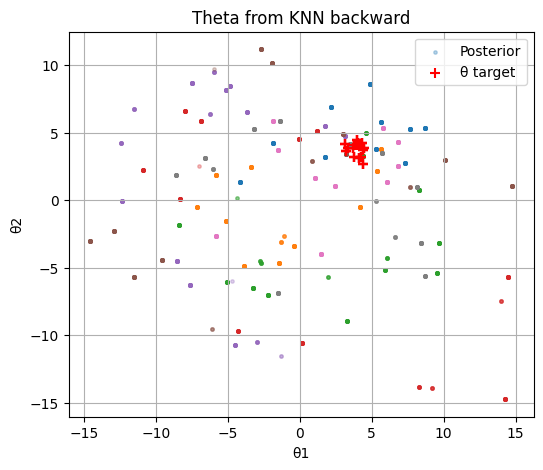

In [3]:
N_SIM, knn, resample_n, a_tol = 500, 10, 5_000, 0.05
_, simulated_data_list = prep_sim_archive(N_SIM, xi_list)

fig, ax = plt.subplots(figsize=(6, 5))
plot_scatter_xi_list(observations, simulated_data_list, a_tol, knn, theta_true_cloud, ax)
plt.show()


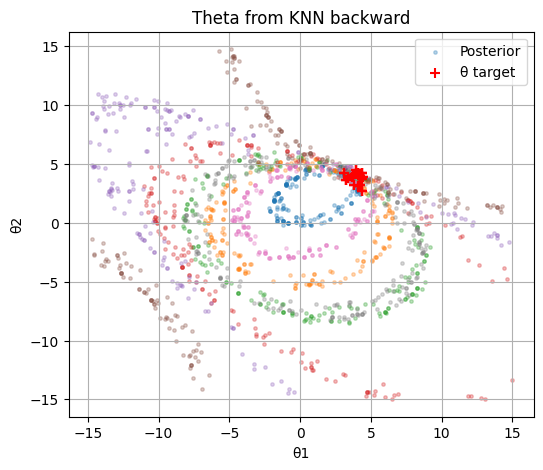

In [4]:
N_SIM = 50_000
fig, AX = plt.subplots(figsize=(6, 5))
_, simulated_data_list = prep_sim_archive(N_SIM, xi_list)
plot_scatter_xi_list(observations, simulated_data_list, a_tol, knn=10, theta_true_cloud=theta_true_cloud, ax=AX)
plt.show()

In [5]:
from src.backward import estimate_p_theta_knn_multi

observed_data_list = [o[0] for o in observations]
xi_star_list = [o[1] for o in observations]

res = estimate_p_theta_knn_multi(observed_data_list, simulated_data_list,  xi_star_list ,
                                 knn=100,  a_tol=0.05, return_full_cov=False, combine_results=True)

In [6]:
# Per experiment objects
per_exp = res["per_experiment"]        # list of length E
E = res["meta"]["n_experiments"]

# Example: experiment e
e = 0
theta_knn_e      = per_exp[e]["theta_samples"]         # (n_obs_e, K_e, d_theta)
indices_local_e  = per_exp[e]["knn_indices"]           # (n_obs_e, K_e), within filtered subset
indices_global_e = per_exp[e]["knn_indices_global"]    # (n_obs_e, K_e), into original archive
epsilon_e        = per_exp[e]["epsilon"]               # (n_obs_e,)
distances_e      = per_exp[e]["output_spread"]["distances"]  # (n_obs_e, K_e)
theta_mean_e     = per_exp[e]["input_spread"]["theta_mean"]  # (n_obs_e, d_theta)
theta_std_e      = per_exp[e]["input_spread"]["theta_std"]   # (n_obs_e, d_theta)
theta_radius     = per_exp[e]["input_spread"]["theta_radius"]  # (n_obs_e, d_theta)
theta_anisotropy      = per_exp[e]["input_spread"]["theta_anisotropy"]   # (n_obs_e, d_theta)

# Combined (stacked) convenience views
theta_knn_all = res["combined"]["theta_samples"]       # (sum n_obs_e, max_K, d_theta) with NaN-pad
epsilon_all   = res["combined"]["epsilon"]             # (sum n_obs_e,)
exp_id_all    = res["combined"]["experiment_index"]    # (sum n_obs_e,)

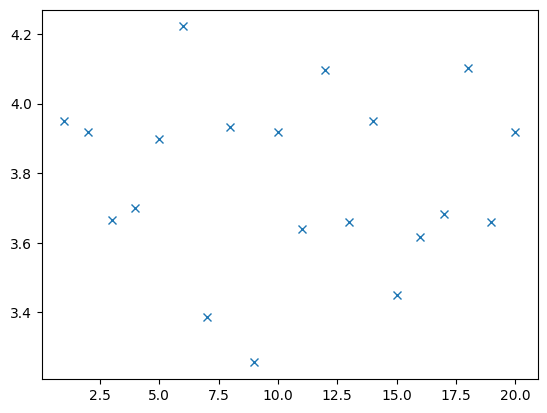

In [7]:
e_index = range(1,len(epsilon_e)+1)
plt.plot(e_index, theta_radius, 'x')


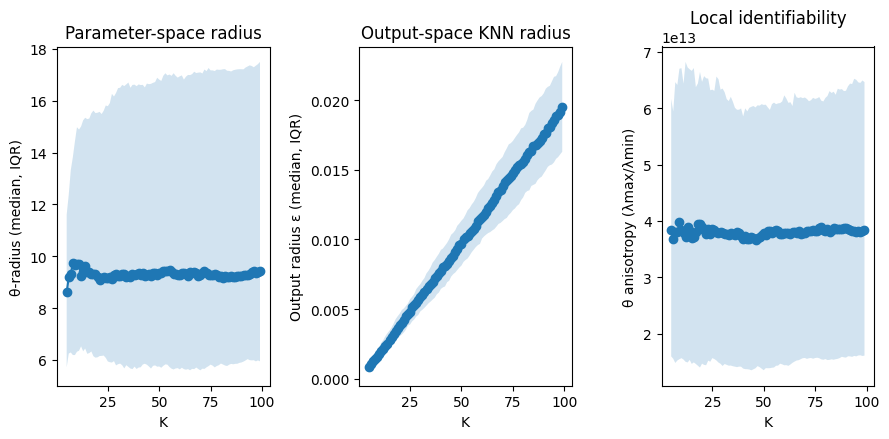

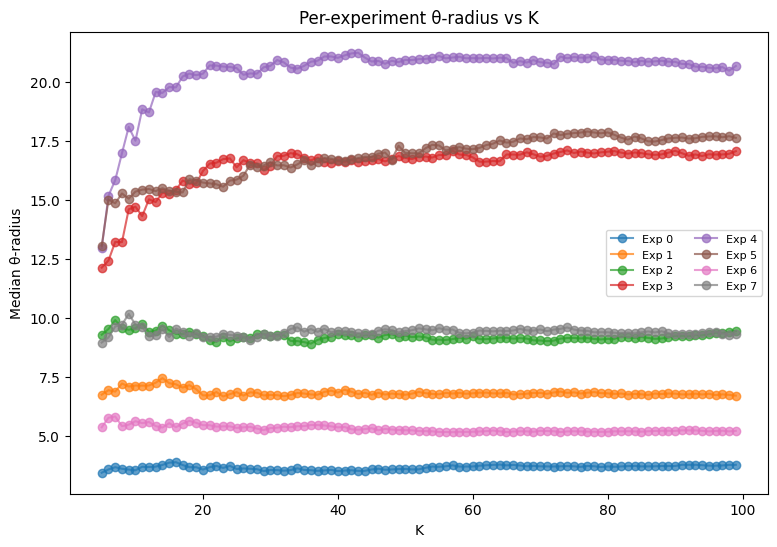

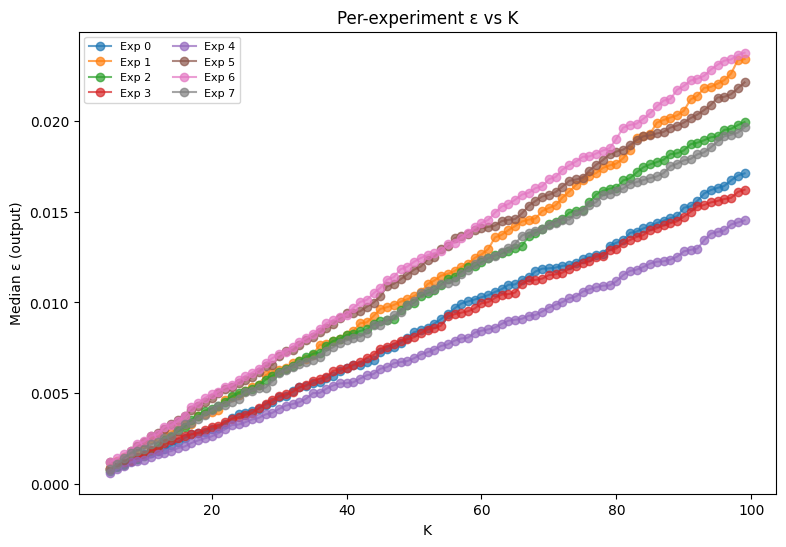

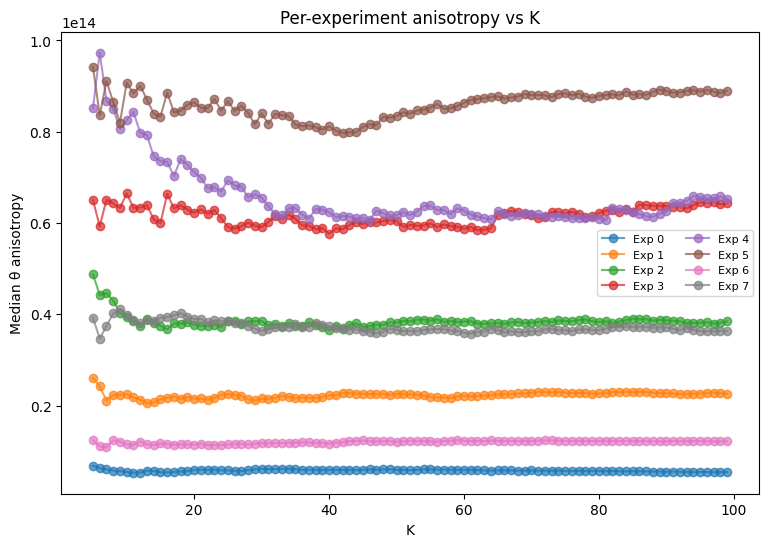

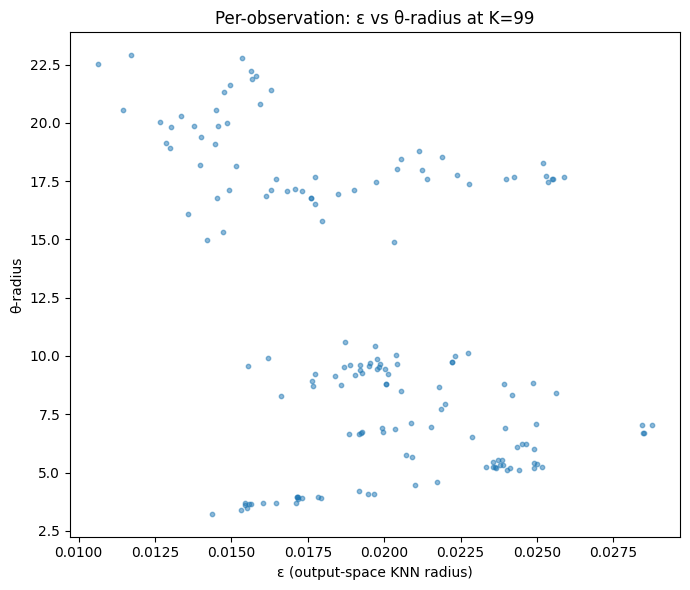

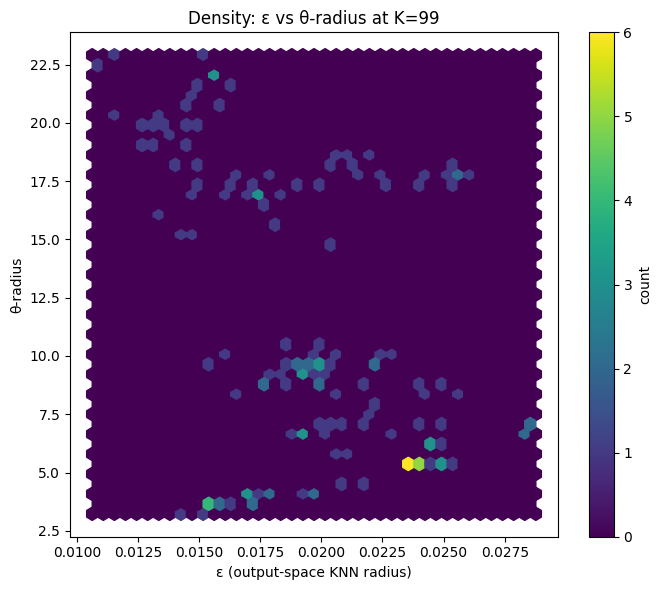

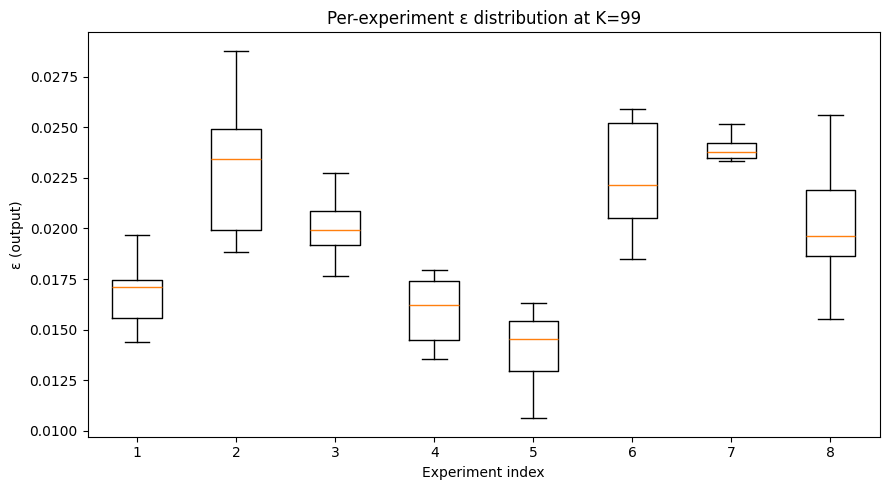

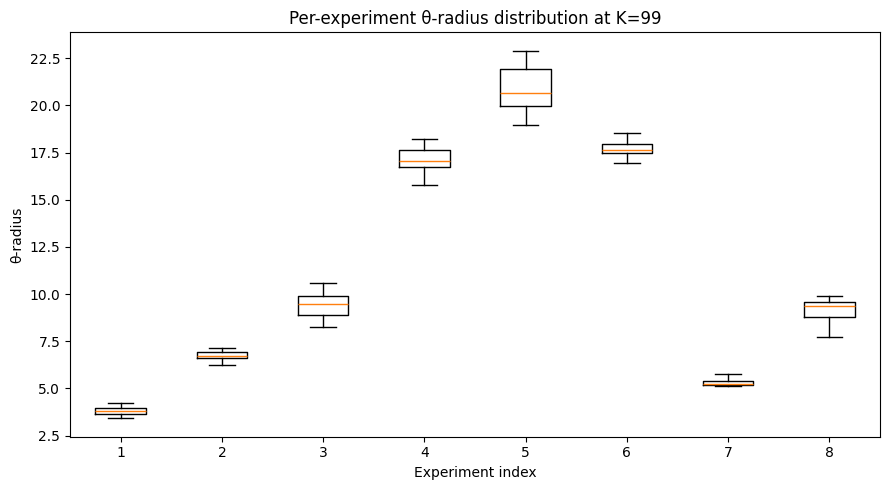

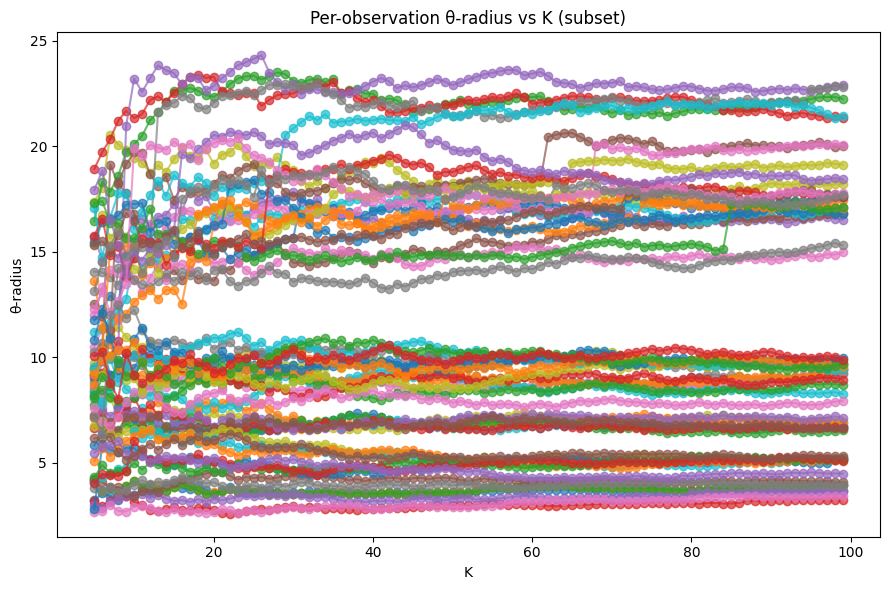

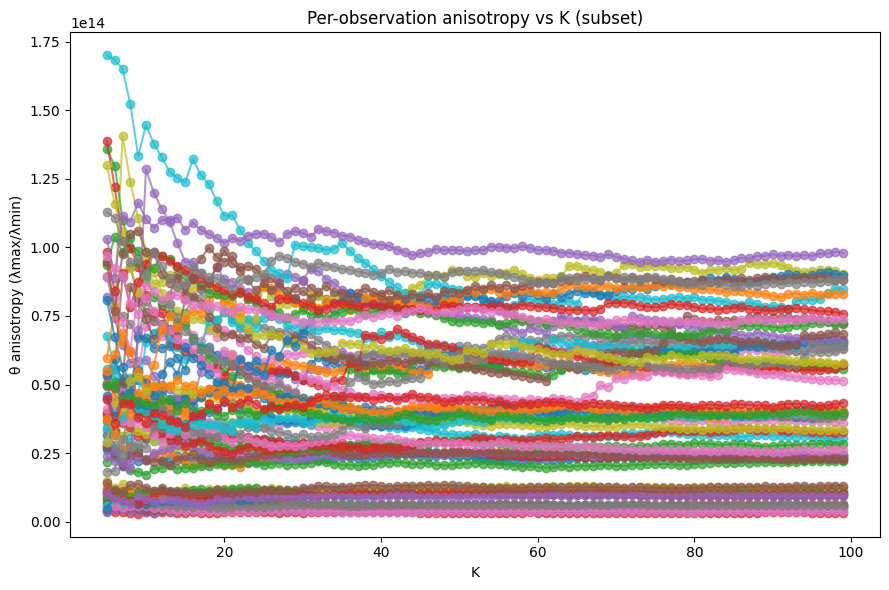

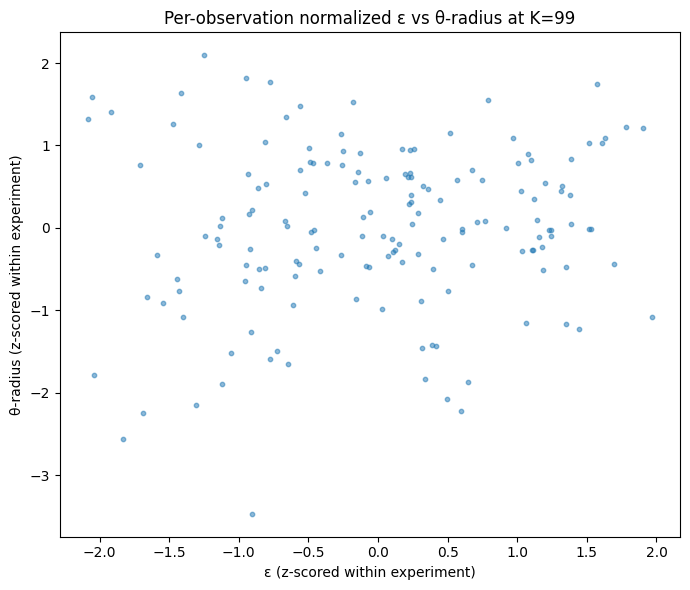

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from src.diagnostics import run_diagnostics_K

run_diagnostics_K(observed_data_list,simulated_data_list,xi_star_list)

In [10]:
import numpy as np

rng = np.random.default_rng(42)

# -------- Multimodal prior over theta (2D) -----------------
def sample_true_uncertainty_model_2d(n, w=0.6):
    """
    Mixture of two Gaussians with different correlations.
    Returns (n, 2).
    """
    n1 = int(np.round(w * n))
    n2 = n - n1
    # Mode A: tight, positively correlated
    mu1 = np.array([1.5, -0.5])
    C1  = np.array([[0.20, 0.15],
                    [0.15, 0.30]])
    th1 = rng.multivariate_normal(mu1, C1, size=n1)
    # Mode B: wider, negatively correlated
    mu2 = np.array([-1.0, 1.2])
    C2  = np.array([[0.60, -0.25],
                    [-0.25, 0.40]])
    th2 = rng.multivariate_normal(mu2, C2, size=n2)
    return np.vstack([th1, th2])



In [11]:
# ------------------ Demo "horse & pony" --------------------
# --- designs (experiments) setup ---
xi_star_list_case2 = [-3.0, -1.0, 0.2, 2.0, 4.0, 8.0, -2.0, 0.1, -6.0, 3.5]  # E = 10
N_emp = 50
N_sim = 50_000

# --- true θ cloud for observations (replicates per experiment) ---
theta_true_cloud = sample_true_uncertainty_model_2d(N_emp)  # (N_emp, 2)

# --- generate observed data per experiment ---
# observations_case2 must be: List[np.ndarray], one array per design e, shape (n_obs_e, d_y)
observations_case2 = []
for xi in xi_star_list_case2:
    y_emp = ridge_switch_model(theta_true_cloud, xi)   # (N_emp, d_y=3)
    observations_case2.append(y_emp)


# --- simulation archive (shared across all experiments) --- # simulation particles
theta_sim = sample_true_uncertainty_model_2d(N_sim)     # (N_sim, 2)  #unknown target

# --- uniform bounds per parameter: [low, high] for θ1 and θ2
THETA_BOUNDS = np.array([[-3.0, 3.0],   # θ1 ∈ [-3, 3]
                         [-3.0, 3.0]])  # θ2 ∈ [-3, 3]

def sample_uniform_theta(n, bounds):
    low  = bounds[:, 0]
    high = bounds[:, 1]
    return np.random.default_rng(0).uniform(low, high, size=(n, bounds.shape[0]))

# global uniform θ used for all experiments


# simulate for ALL experiments and stack
Y_list, Xi_list, Th_list = [], [], []
for xi in xi_star_list_case2:
    theta_sim_uniform = sample_uniform_theta(N_sim, THETA_BOUNDS)    # (N_sim, 2)
    y_sim_e = ridge_switch_model(theta_sim_uniform, xi)                  # (N_sim, 3)
    Y_list.append(y_sim_e)
    Xi_list.append(np.full((N_sim, 1), float(xi)))
    Th_list.append(theta_sim_uniform)                                    # reuse same θ


y_sim = np.vstack(Y_list)        # (E*N_sim, 3)
xi_sim = np.vstack(Xi_list)      # (E*N_sim, 1)
theta_sim_tiled = np.vstack(Th_list)  # (E*N_sim, 2)

# this is what estimate_p_theta_knn_multi expects as 'simulated_data'
simulated_data_case2 = [y_sim, theta_sim_tiled, xi_sim]


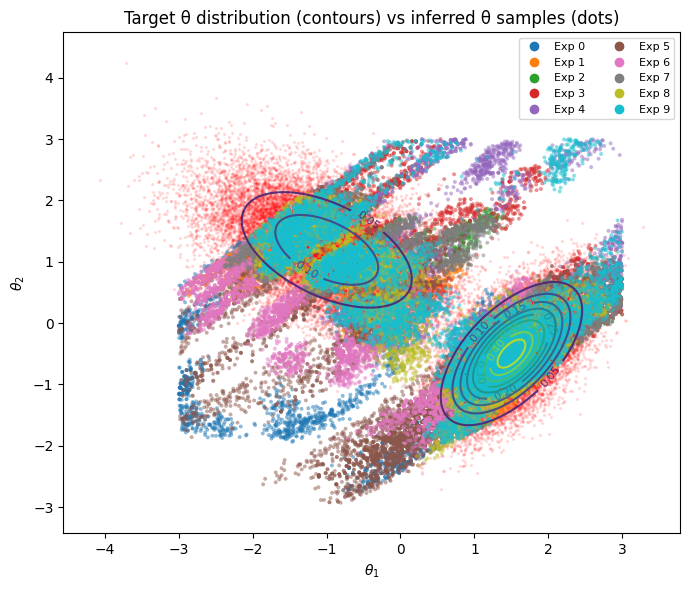

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


res = estimate_p_theta_knn_multi(observations_case2, simulated_data_case2,  xi_star_list_case2 ,
                                 knn=250,  a_tol=0.05, return_full_cov=False, combine_results=True)


# --- 1) get inferred θ samples (flatten, drop NaNs)
Theta_knn = res["combined"]["theta_samples"]            # (sum_nobs, maxK, d_theta)
exp_idx    = res["combined"]["experiment_index"]        # (sum_nobs,)
sum_nobs, maxK, d_theta = Theta_knn.shape
assert d_theta == 2, f"Only 2D plotting supported here (got d_theta={d_theta})."

Theta_knn_flat = Theta_knn.reshape(-1, d_theta)         # (sum_nobs*maxK, 2)
mask = ~np.isnan(Theta_knn_flat).any(axis=1)
Theta_knn_flat = Theta_knn_flat[mask]

# Optional: keep experiment ids aligned with each point (repeat each id maxK times)
exp_idx_rep = np.repeat(exp_idx, maxK)[mask]

# --- 2) get target distribution (archive θ) and fit a GMM as its parametric pdf
# NOTE: simulated_data_case2 = [y_sim, theta_sim_tiled, xi_sim]
theta_archive = theta_sim               # (E*N_sim, 2) tiled across designs
# you can subsample if huge:
# theta_archive = theta_archive[np.random.choice(theta_archive.shape[0], size=10000, replace=False)]

# choose number of components
def fit_gmm_bic(X, max_comp=10):
    best = None
    best_bic = np.inf
    for k in range(1, max_comp+1):
        g = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
        g.fit(X)
        bic = g.bic(X)
        if bic < best_bic:
            best_bic, best = bic, g
    return best

gmm = fit_gmm_bic(theta_archive, max_comp=4)  # or GaussianMixture(2, 'full', 0).fit(theta_archive)

# --- 3) make a grid and evaluate target pdf
all_pts = np.vstack([theta_archive, Theta_knn_flat])
x_min, y_min = all_pts.min(axis=0) - 0.5
x_max, y_max = all_pts.max(axis=0) + 0.5

nx = ny = 250
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                     np.linspace(y_min, y_max, ny))
grid = np.column_stack([xx.ravel(), yy.ravel()])
logpdf = gmm.score_samples(grid)     # log p(θ)
pdf = np.exp(logpdf).reshape(xx.shape)

# --- 4) plot
plt.figure(figsize=(7, 6))
# target distribution contours
cs = plt.contour(xx, yy, pdf, levels=10, alpha=0.9)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

plt.scatter(theta_sim[:,0], theta_sim[:,1], 2, c='r', alpha=0.1)
# inferred θ samples
# color by experiment (optional); otherwise, set c=None and a single color
scatter = plt.scatter(Theta_knn_flat[:,0], Theta_knn_flat[:,1],
                      s=8, alpha=0.5, c=exp_idx_rep, cmap='tab10', edgecolors='none')

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Target θ distribution (contours) vs inferred θ samples (dots)')

# legend for experiments (optional)
if exp_idx_rep is not None:
    handles, labels = [], []
    for e in np.unique(exp_idx_rep):
        handles.append(plt.Line2D([], [], marker='o', linestyle='',
                                  color=scatter.cmap(scatter.norm(e)), label=f'Exp {e}', markersize=6))
        labels.append(f'Exp {e}')
    plt.legend(handles, labels, frameon=True, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


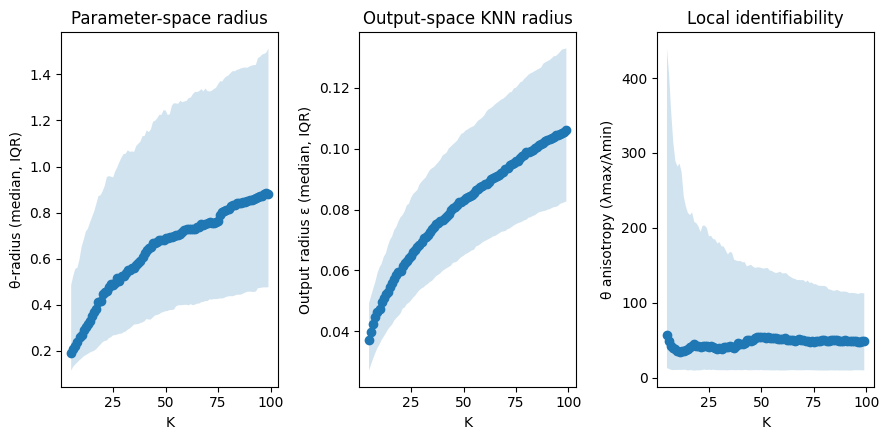

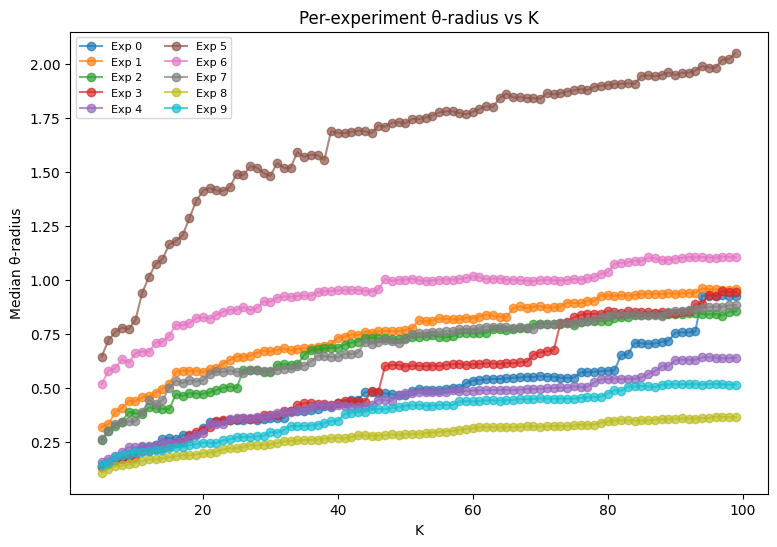

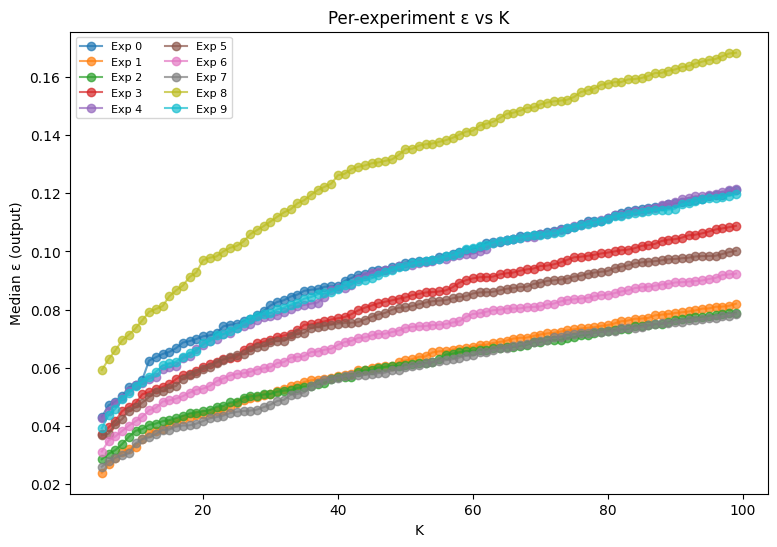

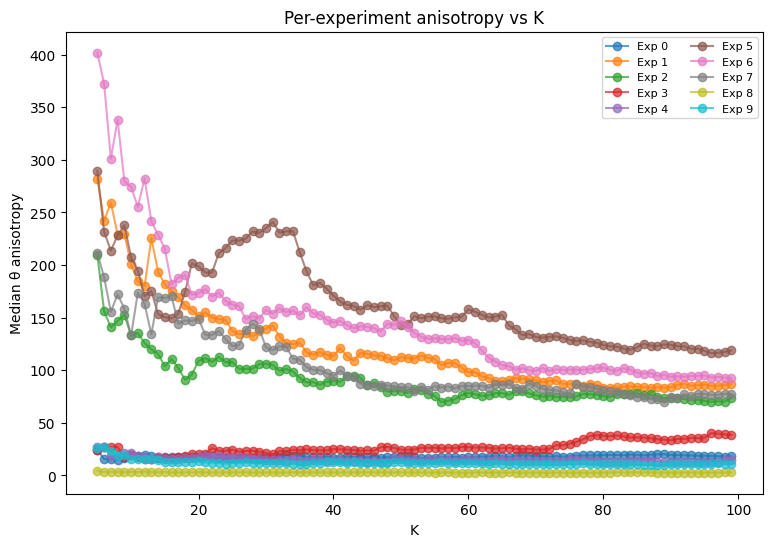

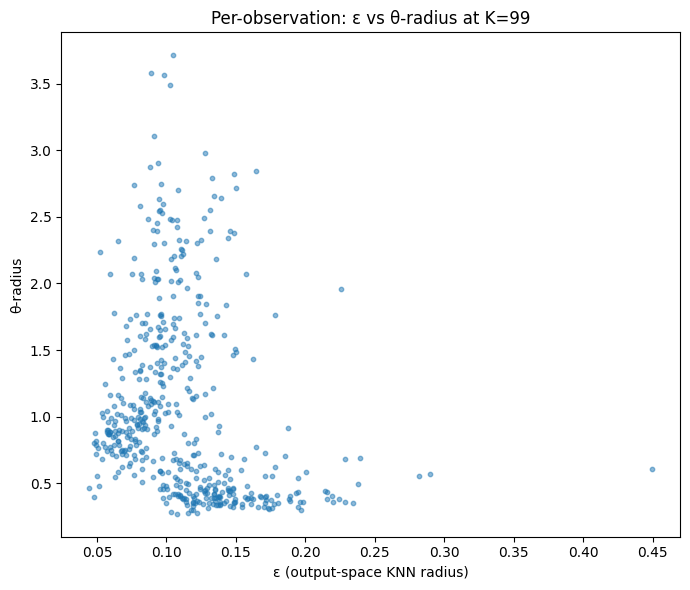

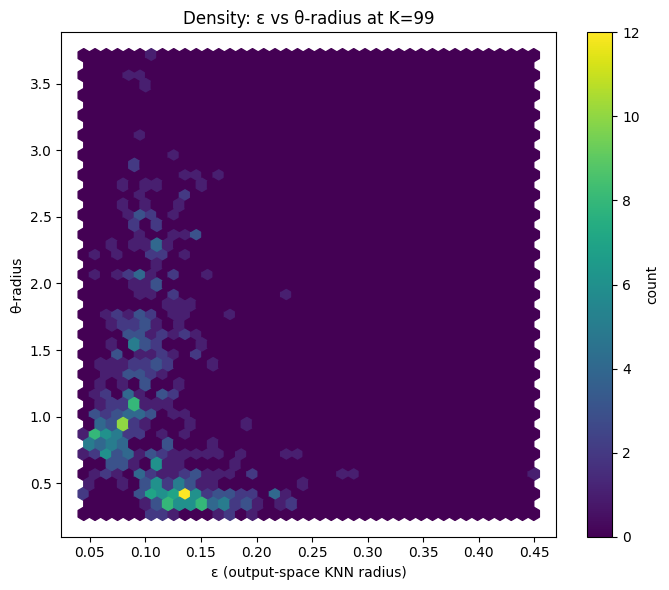

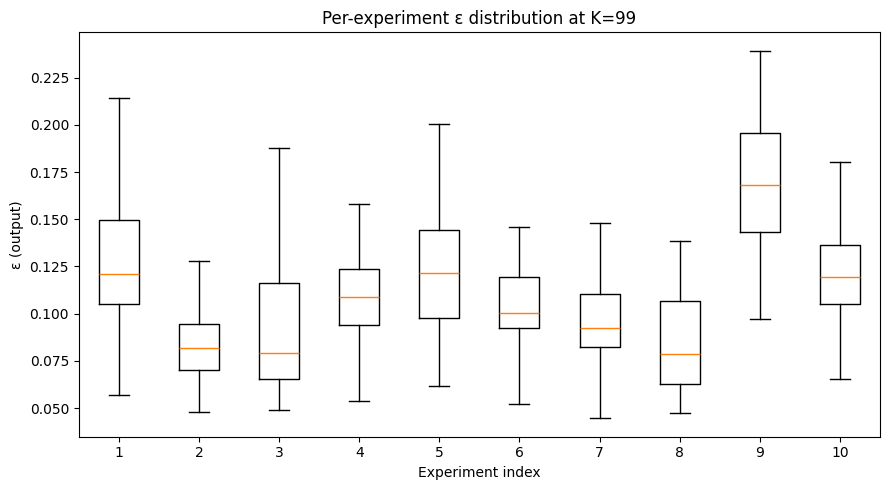

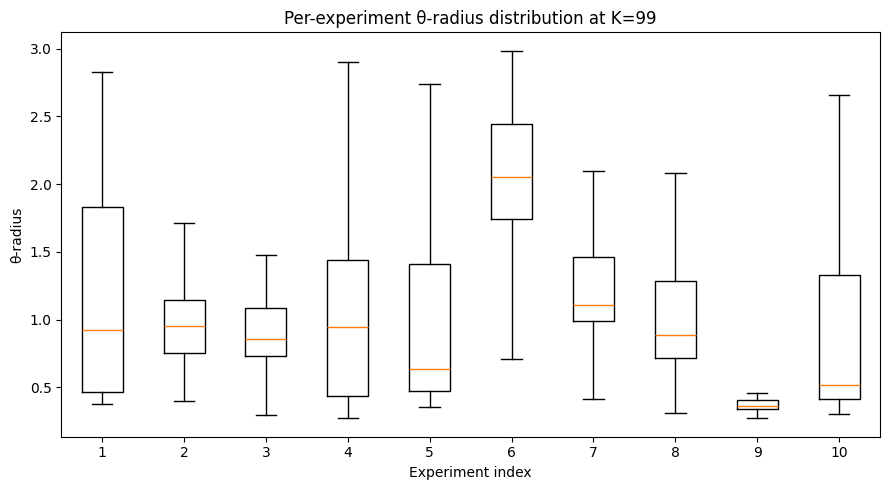

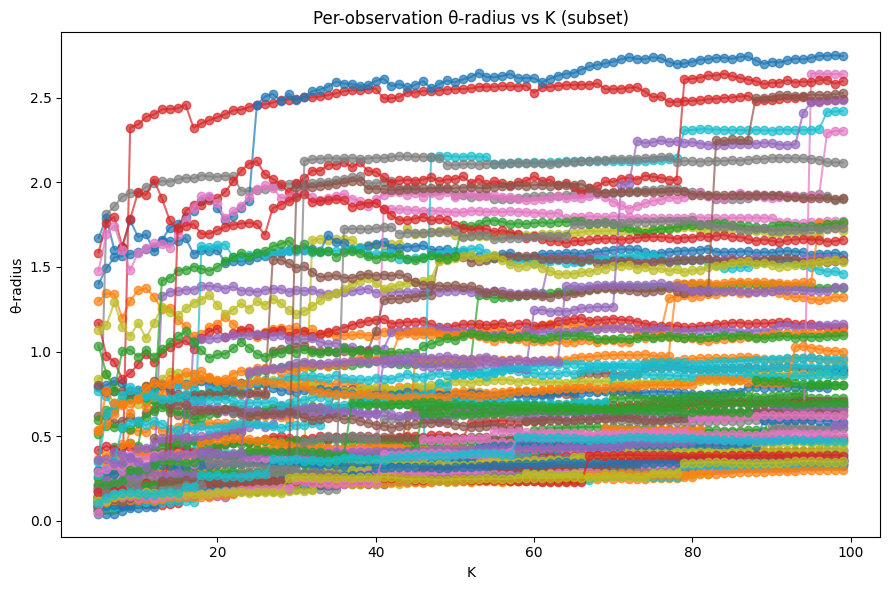

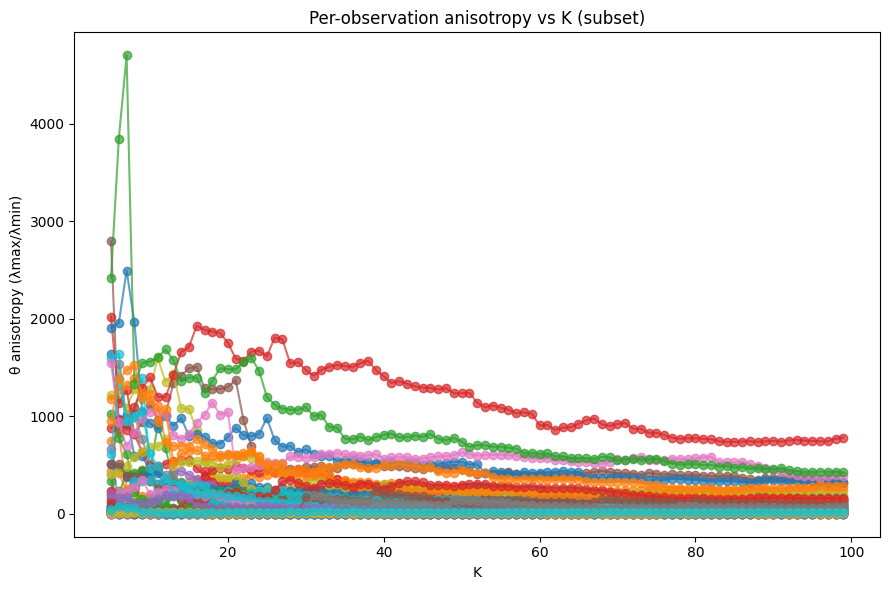

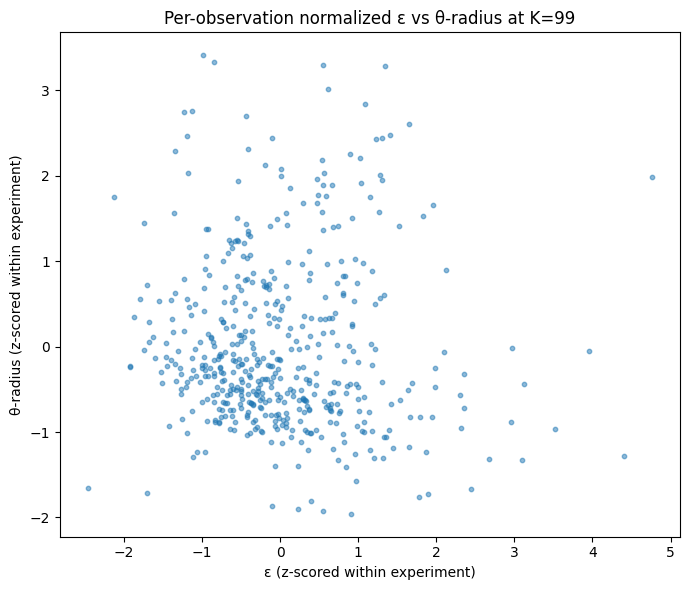

In [13]:

# 3) Call wrapper
run_diagnostics_K(
    observations_case2,          # List of (n_obs_e, d_y)
    simulated_data_case2,        # [y_sim, theta_sim_tiled, xi_sim]
    xi_star_list_case2           # List of designs (length E)
)